In [6]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
import torch.nn.functional as F
from training.models.losses import ArcFaceLoss
from training.models.arcface import MetricLearningModel
import seaborn as sns
import pandas as pd
from tqdm import tqdm
from evaluation.visualize import (
    plot_rejection_scores,
)
from training.models.lightning_wrappers import ResNet
import gpytorch
from torch.utils.data import DataLoader
from utils_notebooks import predict_features, compute_distance_and_visualize
from botorch.models import SingleTaskGP
from botorch.models.transforms import Normalize, Standardize
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.optim import optimize_acqf
from botorch.acquisition import LogExpectedImprovement

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
from toy_scf.models import (
    Backbone,
    train_arcface,
    compute_cosine_sim,
    predict_accuracy,
    load_arcface_model,
    load_scf_model,
    train_scf,
    compute_kappa,
)
from training.dataset_classes.lightning_datasets import CIFAR_N
from torchvision.transforms import InterpolationMode

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        # transforms.Resize(size=112),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
)
# cifar_ds_train = datasets.CIFAR100(
#     root="/app/datasets/cifar100", train=True, download=True, transform=transform
# )
# cifar_ds_test = datasets.CIFAR100(
#     root="/app/datasets/cifar100", train=False, download=True, transform=transform
# )
cifar_ds_train = datasets.CIFAR10(
    root="/app/datasets/cifar10", train=True, download=True, transform=transform
)
cifar_ds_test = datasets.CIFAR10(
    root="/app/datasets/cifar10", train=False, download=True, transform=transform
)
# cifar_ds_train = CIFAR_N(
#     root_dir = '/app/datasets/cifar10',
#         ds_name = 'CIFAR10'
# )
cifar_dl_train = DataLoader(
    cifar_ds_train,
    batch_size=128,
    shuffle=False,
    drop_last=False,
    num_workers=8,
)
cifar_dl_test = DataLoader(
    cifar_ds_test,
    batch_size=128,
    shuffle=False,
    drop_last=False,
    num_workers=8,
)

Files already downloaded and verified
Files already downloaded and verified


In [8]:
from training.models.arcface import MetricLearningModel
from training.models.lightning_wrappers import ResNet
from training.models.losses import ArcFaceLoss

backbone = ResNet(
    "iresnet18_normalized", weights=False, learnable=True, fc_scale=4, num_features=64
)
loss = ArcFaceLoss()
scheduler_params = {
    "scheduler": "OneCycleLR",
    "params": {
        "max_lr": 3e-2,
        "steps_per_epoch": 125,
        "epochs": 20,
        "div_factor": 1e1,
        "final_div_factor": 1e2,
    },
    "interval": "step",
    "frequency": 1,
}
model = MetricLearningModel(
    backbone=backbone,
    loss=loss,
    num_labels=10,
    num_features=64,
    scheduler_params=scheduler_params,
    weight_decay=5e-1,
)

In [9]:
from utils_notebooks import predict_features

model = model.load_from_checkpoint(
    "/app/outputs/arcface_cifar10N_32x32/noisy_dataset/epoch=39-step=5000-v11.ckpt"
)
# model = model.load_from_checkpoint(
#     "/app/outputs/arcface_cifar10N/noisy_dataset_clean/epoch=39-step=2960.ckpt"
# )
# model = model.load_from_checkpoint("/app/outputs/arcface_cifar10/base/last.ckpt")
# predicted_features, image_labels = predict_features(model, cifar_dl_test)
predicted_features, image_labels = predict_features(model, cifar_dl_train)

100%|██████████| 391/391 [00:02<00:00, 184.37it/s]


In [ ]:
# model = model.load_from_checkpoint(
#     "/app/outputs/arcface_cifar10N_32x32/filtered_dataset/epoch=39-step=2960-v1.ckpt"
# )
# torch.save(model.backbone.backbone.state_dict(), '/app/model_weights/cifar10N/clean_backbone/resnet18.pt')
# torch.save(model.softmax_weights, '/app/model_weights/cifar10N/clean_backbone/softmax_weights.pt')

In [10]:
softmax_weights = model.softmax_weights.detach().cpu()
softmax_weights = F.normalize(softmax_weights, dim=1).numpy()

# dists = compute_distance_and_visualize(
#     predicted_features, image_labels, softmax_weights, num_features=64
# )
print(
    f"Test accuracy: {predict_accuracy(predicted_features, image_labels, softmax_weights)}"
)

Test accuracy: 0.58342


In [11]:
file_name = "cifar_10N"
compute_cosine_sim(model, cifar_dl_train, cifar_dl_test, file_name)

100%|██████████| 79/79 [00:00<00:00, 79.94it/s] 


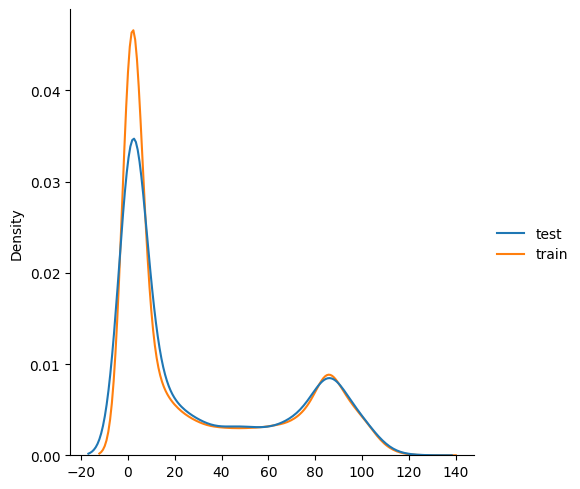

In [12]:
cosine_sim_train = np.load(f"outputs/train_{file_name}_cosine_sim.npy")
cosine_sim_test = np.load(f"outputs/test_{file_name}_cosine_sim.npy")
data = {
    "test": (np.arccos(cosine_sim_test) / (2 * np.pi)) * 360,
    "train": (np.arccos(cosine_sim_train) / (2 * np.pi)) * 360,
}
sns.displot(
    data,
    kind="kde",
    log_scale=False,
    common_norm=False,
)

In [13]:
np.mean(cosine_sim_train[500:600])

0.70728946

In [14]:
cosine_sim_train

array([ 0.99963534,  0.99879277,  0.94829375, ...,  0.9921128 ,
        0.9998888 , -0.16108641], dtype=float32)

In [16]:
np.sum((np.arccos(cosine_sim_train) / (2 * np.pi)) * 360 > 25), len(cosine_sim_train)

(18571, 50000)

In [18]:
(50000 - 18571) / 400

78.5725

### Noisy cifar 10/100

In [1]:
import torch

noise_file = torch.load("/app/datasets/cifar-10-100n-main/data/CIFAR-100_human.pt")
clean_label = noise_file["clean_label"]
noisy_label = noise_file["noisy_label"]

In [7]:
cifar_100_ds_train = datasets.CIFAR100(
    root="/app/datasets/cifar100", train=True, download=True, transform=transform
)

100%|██████████| 169001437/169001437 [00:07<00:00, 21964032.67it/s]


Extracting /app/datasets/cifar100/cifar-100-python.tar.gz to /app/datasets/cifar100


In [11]:
cifar_100_ds_train[3][1]

11

In [12]:
np.mean(noisy_label == clean_label)

0.598

In [4]:
clean_label

array([19, 29,  0, ...,  3,  7, 73])

In [1]:
from training.dataset_classes.lightning_datasets import CIFAR

ds = CIFAR("/app/datasets/cifar100", train=True, ds_name="CIFAR100")
ds10 = CIFAR("/app/datasets/cifar10", train=True, ds_name="CIFAR10")

Files already downloaded and verified
Files already downloaded and verified


In [2]:
ds[1][1]

/home/l.erlygin/miniconda/lib/python3.9/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


29

In [12]:
ds[0][1]

19

In [13]:
ds10[0][1]

6

In [6]:
ds[0][0].shape

torch.Size([3, 112, 112])